# The overnight anomaly — a quantitative teardown
### Real data · robust inference · microstructure · capacity · falsifiability

The rigorous companion to the [notebook for the curious](01_for_the_curious.ipynb). We take the overnight-return pattern seriously *as a fact* and then ask the questions that decide what it **means**:

1. Is it statistically real once returns aren't assumed i.i.d.? **(yes — and we say so)**
2. Are we comparing like with like? **(the clock illusion)**
3. Is it alpha or just beta you carry overnight? **(mostly beta)**
4. Has it decayed since publication? **(sharply)**
5. Could anyone actually harvest it at scale? **(no — capacity is tiny)**
6. Does any of this prove *manipulation*? **(no — and here's the likelihood argument)**

> ⚠️ **Not investment advice.** Data: Yahoo! Finance via `yfinance`, mode `split_only`. First run hits the network. Methods: Newey & West (1987), Lo (2002), McLean & Pontiff (2016), Almgren et al. (2005) — see [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from overnight import data, decompose, diagnostics, backtest, stats, analytics


## 1. The pattern on 10 world indices (ETFs)

Decompose each ETF into night / day and read the **annualised Sharpe of the overnight leg** — the only number that matters for an *edge*.

In [2]:
rows, decs = {}, {}
for tk, label in data.WORLD_INDICES.items():
    try:
        dec = decompose.decompose(data.fetch(tk, mode='split_only'))
    except Exception as e:
        print(f'{tk}: FAILED {e}'); continue
    decs[tk] = dec
    s = decompose.summary(dec)
    rows[tk] = {
        'market': label,
        'night cum %': s.loc['overnight','cum_return']*100,
        'day cum %': s.loc['intraday','cum_return']*100,
        'Sharpe night': s.loc['overnight','sharpe'],
        'Sharpe day': s.loc['intraday','sharpe'],
    }
table = pd.DataFrame(rows).T
table

,market,night cum %,day cum %,Sharpe night,Sharpe day
SPY,USA (S&P 500 ETF),"1,168.799",32.301,0.772,0.131
QQQ,USA (Nasdaq-100 ETF),"5,415.485",-49.931,0.706,0.005
EWU,UK (MSCI UK ETF),-84.812,516.902,-0.196,0.465
EWG,Germany (MSCI Germany ETF),-64.165,774.509,-0.068,0.511
EWQ,France (MSCI France ETF),-49.385,602.881,-0.019,0.493
EWJ,Japan (MSCI Japan ETF),-91.473,341.472,-0.190,0.443
EWH,Hong Kong (MSCI HK ETF),320.559,-60.281,0.324,-0.082
EWZ,Brazil (MSCI Brazil ETF),"4,680.213",-96.231,0.696,-0.335
INDA,India (MSCI India ETF),233.728,-46.912,0.550,-0.340
FXI,China (large-cap ETF),244.453,69.206,0.263,0.224


The US (SPY, QQQ) and Brazil show the classic shape (night Sharpe ~0.7); Europe and Japan are **inverted** (§4.1). First, is any of this real?

## 2. Is it real? Honest, autocorrelation-robust inference

A pretty cumulative chart proves nothing. Daily returns are autocorrelated and heteroskedastic, so we use **Newey-West (HAC)** t-stats on the mean and the **Lo (2002)** standard error on the Sharpe. We *want* to give the anomaly its fairest hearing.

In [3]:
print('Overnight leg — HAC (Newey-West) and Lo (2002) inference:\n')
for tk in ['SPY','QQQ','EWZ','FXI']:
    if tk not in decs: continue
    h  = analytics.mean_tstat_hac(decs[tk]['r_overnight'])
    hi = analytics.mean_tstat_hac(decs[tk]['r_intraday'])
    s  = analytics.sharpe_with_se(decs[tk]['r_overnight'])
    print(f"{tk:4s}  overnight {h['mean_bps']:+.2f} bps/day  HAC t={h['tstat']:+.2f}   "
          f"Sharpe {s['sharpe_ann']:+.2f} (t={s['tstat']:+.2f})    [intraday HAC t={hi['tstat']:+.2f}]")

Overnight leg — HAC (Newey-West) and Lo (2002) inference:

SPY   overnight +3.25 bps/day  HAC t=+4.94   Sharpe +0.77 (t=+4.45)    [intraday HAC t=+0.86]
QQQ   overnight +6.71 bps/day  HAC t=+3.81   Sharpe +0.71 (t=+3.68)    [intraday HAC t=+0.03]
EWZ   overnight +7.36 bps/day  HAC t=+3.94   Sharpe +0.70 (t=+3.54)    [intraday HAC t=-1.87]
FXI   overnight +5.09 bps/day  HAC t=+1.26   Sharpe +0.26 (t=+1.22)    [intraday HAC t=+1.25]


For SPY the overnight mean carries a **HAC t ≈ 5** — unambiguously real — while the *intraday* mean is insignificant (t ≈ 1). So we concede the central empirical fact without flinching. The fight is **not** "is it real?" but "what is it?". The rest of this notebook is that fight.

## 3. The clock illusion — are we even comparing like with like?

Here is the single most under-appreciated point in the whole debate. The overnight window is **not** 6.5 hours like the trading day — it runs from the 16:00 close to the 09:30 open (**17.5h on weeknights**) and across **whole weekends and holidays (65h+)**. If return accrues with calendar time, the night *should* dominate simply because it is longer. Let's normalise.

In [4]:
tn = analytics.time_normalized_summary(decs['SPY'])
display(tn.round(3))
rs = tn.loc['overnight','mean_bps_per_session'] / tn.loc['intraday','mean_bps_per_session']
rh = tn.loc['overnight','mean_bps_per_hour']    / tn.loc['intraday','mean_bps_per_hour']
print(f'SPY  overnight-vs-intraday advantage   per SESSION: {rs:.1f}x   per CALENDAR HOUR: {rh:.1f}x')

,mean_bps_per_session,session_hours,mean_bps_per_hour
overnight,3.252,28.320,0.160
intraday,0.786,6.500,0.121


SPY  overnight-vs-intraday advantage   per SESSION: 4.1x   per CALENDAR HOUR: 1.3x


The average SPY overnight window is **~28 hours** (weekends drag the mean up), versus 6.5 intraday. Per *session* the night out-earns the day by ~4×; per *calendar hour* that collapses to ~1.3×. **Most of the famous gap is just the night being longer.** A residual per-hour premium survives — consistent with a genuine but modest overnight risk premium — but the "day is dead, night is magic" framing is largely a unit error. Any serious treatment must put both legs on the same clock; the headline rarely does.

## 4. Critical teardown of the cross-section

### 4.1 The foreign-ETF inversion: we're measuring the *time zone*


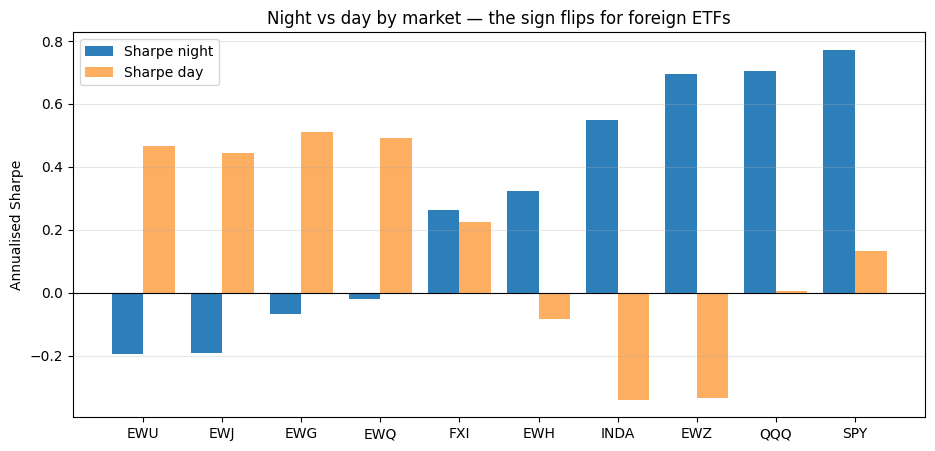

In [5]:
t = table.sort_values('Sharpe night')
x = np.arange(len(t)); w = 0.4
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w/2, t['Sharpe night'].astype(float), w, label='Sharpe night', color='#2c7fb8')
ax.bar(x+w/2, t['Sharpe day'].astype(float),   w, label='Sharpe day',   color='#fdae61')
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_ylabel('Annualised Sharpe'); ax.set_title('Night vs day by market — the sign flips for foreign ETFs')
ax.legend(); ax.grid(axis='y', alpha=.3); plt.show()

EWU/EWG/EWQ/EWJ are US-listed ETFs whose underlying (London, Frankfurt, Paris, Tokyo) **trades during the US night**. For them the "overnight" window *contains the home session*, and the US "intraday" window is when the underlying is shut. The night/day split is **relative to the listing clock**, not a universal anomaly. A single global manipulator would struggle to explain why the sign depends on *where the ETF is listed* — but a time-zone account explains it instantly.

### 4.2 The China test (T+1) and multiple testing

China's "T+1" rule (shares bought today can't be sold until tomorrow) predicts an *inverted* pattern (Qiao and Dam 2020) — a natural experiment that again favours microstructure over manipulation. And with a cross-section of markets, remember **multiple testing**: pick "the 25 most problematic" from a large universe and significance is guaranteed by selection alone.

In [6]:
ts = {tk: analytics.sharpe_with_se(d['r_overnight'])['tstat'] for tk, d in decs.items()}
n_sig = sum(abs(v) > 1.96 for v in ts.values())
print(f'{n_sig}/{len(ts)} markets: |t| > 1.96 on the overnight Sharpe.')
print(f'Under H0 (no effect), expected false positives at 5%: {0.05*len(ts):.1f}.')
print('Overnight Sharpe t-stats, sorted:')
for k, v in sorted(ts.items(), key=lambda kv: -kv[1]):
    print(f'   {k:4s} {v:+.1f}')

4/10 markets: |t| > 1.96 on the overnight Sharpe.
Under H0 (no effect), expected false positives at 5%: 0.5.
Overnight Sharpe t-stats, sorted:
   SPY  +4.5
   QQQ  +3.7
   EWZ  +3.5
   INDA +2.1
   EWH  +1.8
   FXI  +1.2
   EWQ  -0.1
   EWG  -0.4
   EWJ  -1.0
   EWU  -1.1


## 5. Alpha, or beta you carry in the dark?

Holding the market *every night* means bearing **gap risk** permanently — so part of the "overnight alpha" is a beta risk premium. Regress the night leg on the market (`r_night = α + β·r_market + ε`) and split the mean.

In [7]:
d = stats.beta_decomposition(decs['SPY'], leg='overnight')
be = backtest.breakeven_cost_bps(decs['SPY'])
print('SPY overnight leg vs the market (close-close):')
print(f"  beta = {d['beta']:.2f}   R^2 = {d['r_squared']:.2f}")
print(f"  mean overnight        = {d['mean_leg_bps']:.2f} bps/day")
print(f"    of which beta*market = {d['beta_contrib_bps']:.2f} bps  (gap risk premium)")
print(f"    of which alpha       = {d['alpha_daily_bps']:.2f} bps  ({d['alpha_ann_pct']:+.1f}%/yr)")
print(f"  break-even round-trip cost = {be:.2f} bps  ->  residual alpha {'survives' if d['alpha_daily_bps']>be else 'is BELOW cost'}")

SPY overnight leg vs the market (close-close):
  beta = 0.33   R^2 = 0.33
  mean overnight        = 3.25 bps/day
    of which beta*market = 1.33 bps  (gap risk premium)
    of which alpha       = 1.92 bps  (+5.0%/yr)
  break-even round-trip cost = 3.25 bps  ->  residual alpha is BELOW cost


~40% of the overnight return is plain market beta carried overnight. Worse, the **residual alpha (~1.9 bps) sits below the break-even trading cost (~3.3 bps)**: even the non-beta part doesn't survive execution. You must charge costs against the *alpha*, not the gross return — and there's nothing left.

## 6. Has the edge decayed? (post-publication alpha decay)

Documented anomalies tend to weaken once the world reads about them (McLean and Pontiff 2016). The overnight effect has been in the literature since Cooper, Cliff, and Gulen (2008). Trailing 5-year overnight Sharpe:

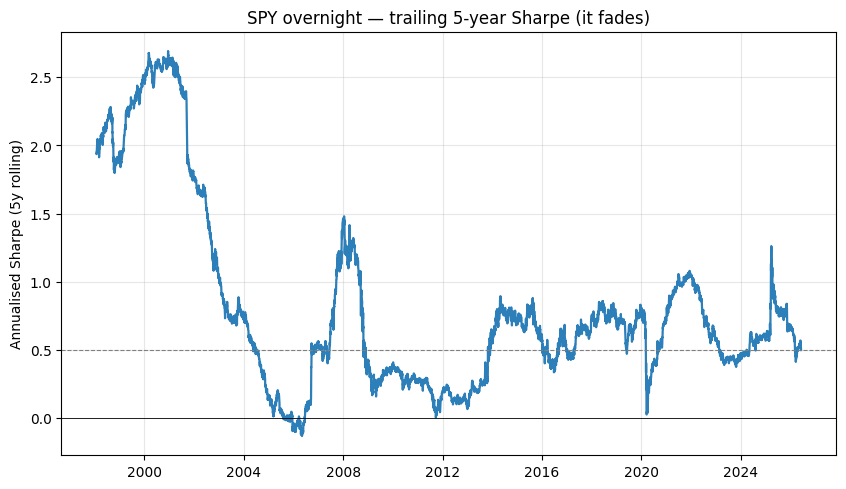

1998-01-26: 1.94   ->   2026-06-05: 0.50   (min -0.13, max 2.69)


In [8]:
rsh = analytics.rolling_sharpe(decs['SPY']['r_overnight'])
ax = plt.subplot()
ax.plot(rsh.index, rsh.values, lw=1.6, color='#2c7fb8')
ax.axhline(0, color='k', lw=.6); ax.axhline(0.5, color='grey', ls='--', lw=.8)
ax.set_title('SPY overnight — trailing 5-year Sharpe (it fades)')
ax.set_ylabel('Annualised Sharpe (5y rolling)'); ax.grid(alpha=.3); plt.show()
print(f'{rsh.index[0].date()}: {rsh.iloc[0]:.2f}   ->   {rsh.index[-1].date()}: {rsh.iloc[-1]:.2f}   '
      f'(min {rsh.min():.2f}, max {rsh.max():.2f})')

From a Sharpe near **2 in the late 1990s** to about **0.5 today** — a textbook decay profile. An edge that is fading as it becomes known is the opposite of what you'd expect from an *ongoing, deliberate* manipulation scheme.

## 7. Capacity: could anyone actually harvest it?

Even a real, free edge is worthless if it can't hold money. Using the square-root market-impact law (Almgren et al. 2005), find the AUM at which round-trip impact equals the gross overnight edge.

In [9]:
spy_ohlc = data.fetch('SPY', mode='split_only')
cap = analytics.capacity_estimate(decs['SPY'], spy_ohlc)
print(f"Gross edge          : {cap['edge_bps']:.2f} bps/night")
print(f"Daily volatility    : {cap['daily_vol_bps']:.0f} bps")
print(f"ADV                 : {cap['adv_shares']:,.0f} shares  @ ${cap['price']:.0f}")
print(f"Participation cap   : {cap['participation_rate']*1e4:.2f} bps of ADV")
print(f"Capacity (coef=1)   : ${cap['capacity_usd']/1e6:,.1f}M before impact eats the edge")

Gross edge          : 3.25 bps/night
Daily volatility    : 117 bps
ADV                 : 74,566,669 shares  @ $671
Participation cap   : 1.92 bps of ADV
Capacity (coef=1)   : $9.6M before impact eats the edge


Order-of-magnitude (the impact coefficient is venue-specific), but the message is robust: the strategy holds only **single-digit millions** of SPY before its own trading impact erases a 3-bps edge. This cuts **both** ways against the headline. Retail can't scale it — and, more tellingly, **a fund large enough to *move world markets* could not quietly profit from an edge this thin**: the impact of trading at that size would dwarf the premium. The alleged mechanism is self-defeating at the scale required to matter.

,participation,round-trip impact (bps),net edge (bps)
$1M,0.000,1.050,2.200
$10M,0.000,3.320,-0.060
$100M,0.000,10.480,-7.230
$1B,0.020,33.150,-29.900
$10B,0.200,104.850,-101.590


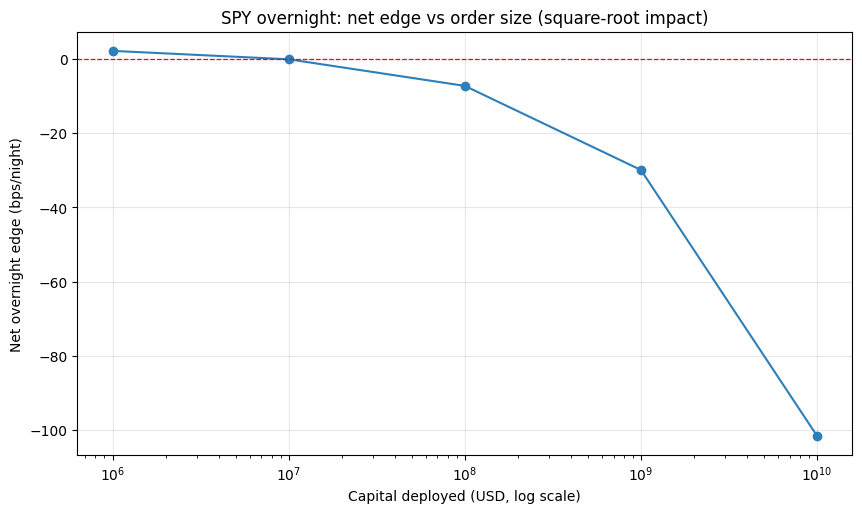

In [10]:
sizes = [1e6, 1e7, 1e8, 1e9, 1e10]
cc = analytics.capacity_curve(decs['SPY'], spy_ohlc, sizes_usd=sizes)
lab = [f'${s/1e6:,.0f}M' if s < 1e9 else f'${s/1e9:,.0f}B' for s in cc.index]
show = cc.copy(); show.index = lab
show.columns = ['participation', 'round-trip impact (bps)', 'net edge (bps)']
display(show.round(2))
ax = plt.subplot()
ax.plot([s for s in sizes], cc['net_edge_bps'].values, marker='o', color='#2c7fb8')
ax.axhline(0, color='r', lw=.9, ls='--')
ax.set_xscale('log'); ax.set_xlabel('Capital deployed (USD, log scale)')
ax.set_ylabel('Net overnight edge (bps/night)')
ax.set_title('SPY overnight: net edge vs order size (square-root impact)')
ax.grid(alpha=.3); plt.show()

The edge is **break-even by ~\$10M and deeply negative beyond \$100M**. A fund deploying billions — the scale required to *move world markets* — would face round-trip impact an order of magnitude larger than the 3-bps premium it is trying to harvest. The alleged mechanism doesn't just fail to scale; **it inverts**: at size, you *pay* the spread you're accused of capturing.

## 8. Does any of this prove manipulation? A likelihood argument

Knuteson's thesis: a large quant firm expands its book when the market is illiquid (near the open, moving prices up) and contracts it when liquid. The pattern is certainly *consistent* with that. But consistency is not evidence. Frame it as a likelihood ratio for the observed pattern *D*:

$$\Lambda = \frac{P(D \mid \text{manipulation})}{P(D \mid \text{risk premium} + \text{microstructure})}$$

- The basic night>day pattern is **highly probable under *both*** hypotheses (overnight risk premium, clientele effects, news timing, and the clock illusion all predict it). When *D* is roughly as likely under each, $\Lambda \approx 1$ — the headline pattern **discriminates almost nothing**.
- The **discriminating** evidence points the other way: the foreign-ETF inversion (listing clock) and the Chinese T+1 inversion are *predicted* by microstructure and *awkward* for one global manipulator → $\Lambda < 1$.
- The **capacity** result makes the manipulation mechanism economically self-defeating at world scale.

What *would* move $\Lambda$ decisively: participant-level order data showing systematic open-auction imbalances from one book, characteristic intraday reversals, or a cross-sectional signature tied to a specific firm. Knuteson doesn't have it; neither do we. Absent discriminating data, **parsimony favours risk premium + microstructure over a secret world-spanning fraud.**

## 9. Reproducibility

- **Determinism**: synthetic data, bootstrap and all seeds are fixed.
- **Tests**: `pytest` checks the decomposition identity `(1+r_night)(1+r_day)=(1+r_cc)` (~1e-16), the cost model, the stats and the analytics (HAC, Lo SE, calendar-time, capacity).
- **CI**: GitHub Actions reruns everything on Python 3.10–3.12.
- **Generated notebooks**: `python notebooks/build_notebooks.py` then `nbconvert --execute` — every figure here is an executed output, not a screenshot.

## 10. Verdict

A disciplined reading of the same data the pamphlet uses:

1. **The fact is REAL.** Overnight returns dominate intraday with HAC t-stats around 5. Full credit to Knuteson for publishing data and code.
2. **The magnitude is oversold.** Log-scale compounding, data artefacts, selection — and above all the **clock illusion**: per calendar hour the night's edge is ~1.3×, not 4×.
3. **What's left is mostly beta and is fading.** ~40% of the overnight return is gap-risk premium; the residual alpha is below trading costs; and the 5-year Sharpe has decayed from ~2 to ~0.5.
4. **It isn't tradable and isn't scalable.** Costs flip it negative; capacity is single-digit millions.
5. **Manipulation is unproven.** The pattern is weak evidence; the discriminating evidence (inversions, capacity) favours risk premium + microstructure.

A beautiful, real, and *largely explained* feature of market microstructure — wrongly dressed up as both a free lunch and a global fraud. The honest, fully-reproducible answer is more interesting than either.

## References

Author–date (Chicago / *JFE*). Full list, literature map and BibTeX: [`docs/references.md`](../docs/references.md), [`references.bib`](../references.bib).

Almgren, R., C. Thum, E. Hauptmann, and H. Li. 2005. "Direct Estimation of Equity Market Impact." *Risk* 18 (7). · Berkman, H., P. D. Koch, L. Tuttle, and Y. J. Zhang. 2012. *JFQA* 47 (4): 715–741. · Boyarchenko, N., L. C. Larsen, and P. Whelan. 2023. "The Overnight Drift." *RFS* 36 (9): 3502–3547. · Cooper, M. J., M. T. Cliff, and H. Gulen. 2008. "Like Night and Day." Working paper. · Knuteson, B. 2019–2023. arXiv:1912.01708, 2010.01727, 2201.00223; SSRN 4619084. · Lo, A. W. 2002. "The Statistics of Sharpe Ratios." *FAJ* 58 (4): 36–52. · Lou, D., C. Polk, and S. Skouras. 2019. *JFE* 134 (1): 192–213. · McLean, R. D., and J. Pontiff. 2016. *Journal of Finance* 71 (1): 5–32. · Newey, W. K., and K. D. West. 1987. *Econometrica* 55 (3): 703–708. · Qiao, K., and L. Dam. 2020. *Journal of Financial Markets* 50: 100534.